In [3]:
using Sockets
using CUDA
using PulsePropagation
using CSV
using DelimitedFiles
using NPZ
using FFTW
using Statistics

println("Host: ", gethostname())
println("Slurm job: ", get(ENV, "SLURM_JOB_ID", "missing"))
println("GPU: ", CUDA.name(CUDA.device()))
println("CUDA functional: ", CUDA.functional())

Host: c0003
Slurm job: 235938
GPU: NVIDIA H100 80GB HBM3
CUDA functional: true


In [4]:
ENV["GKSwstype"] = "100"

using Plots
Plots.gr()

Plots.GRBackend()

In [5]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^13;
time_window = 100; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength
λ_nm = 1e9 * λ;

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);

In [7]:
core_radius = 55e-6;
NA = 0.1;
material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = StepIndex(λ0, core_radius, NA);

mode_number_list = [10:10:120;]
num_modes = mode_number_list[end]; 

properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3)
coefficients = ones(ComplexF64, num_modes) 

initial_field = gaussian_pulse(
        domain,
        num_modes;
        peak_power=1e6,    # total peak power across all modes, W
        fwhm=0.25,          # intensity FWHM, ps
        time_offset=0,  # ps
        coefficients=coefficients,
    );


In [8]:
error_list = [1e-2, 1e-3, 1e-4];
cp_rank_table = zeros(length(mode_number_list), length(error_list));

rhs_timing_list = zeros(length(mode_number_list), length(error_list));

dz_forward = 50e-6;
n_steps = 250;
L_fiber = n_steps * dz_forward;

In [ ]:
for ii = 1:length(error_list)
    err = error_list[ii];

    for mm = 1:length(mode_number_list)

        num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ### Constructing CP decomposition
        S_compressed = cp_compress(
                        S_m;
                        error=err,
                        backend=:cuda,
                        min_rank=2,       # choose using previous experience
                        rank_step=25,       # or 64
                        max_rank=1500,
                        maxiter=120,
                        tolerance=1e-6,
                        ridge=1e-8,
                        check_every=5,
                        )

        cp_rank_table[mm,ii] = length(S_compressed.λ)

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_compressed,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda_cp_optimized, precision=:mixed,
            adaptive=false);

        rhs_timing_list[mm,ii] = tsol / n_steps;

    end
end

10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120


In [ ]:
## collect dense timing

dense_timing_list = zeros(length(mode_number_list));

for mm = 1:length(mode_number_list)
        
    num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_m,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda, precision=:mixed,
             adaptive=false);

        #tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda);

        dense_timing_list[mm] = tsol / n_steps;

end

10
20
30
40
50
60
70
80
90
100
110
120


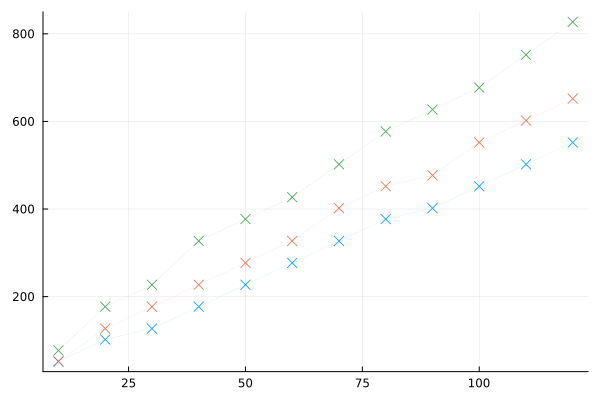

In [11]:
p = plot(mode_number_list, cp_rank_table, line=false, marker=:x, label=false, markersize=5)
display(p)

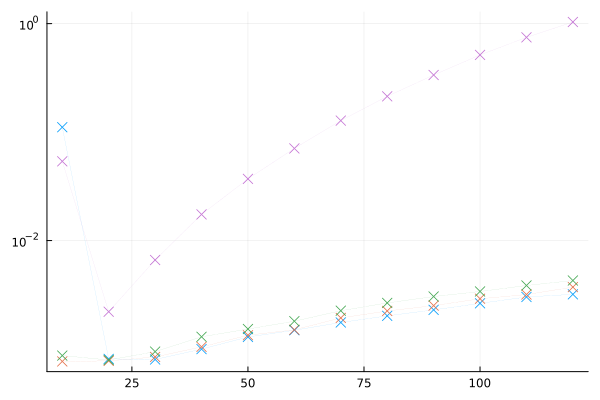

In [12]:
p = plot(mode_number_list, rhs_timing_list, line=false, marker=:x, label=false, markersize=5,yscale=:log10)
plot!(mode_number_list, dense_timing_list, line=false, marker=:x, label=false, markersize=5)

In [19]:
npzwrite("mode_number_list.npy", mode_number_list)
npzwrite("cp_rank_table_step.npy", cp_rank_table)
npzwrite("rhs_timing_list_cp_step.npy", rhs_timing_list)
npzwrite("dense_timing_list_step.npy", dense_timing_list)

Same for GRIN

In [20]:
core_radius = 52.5e-6;
NA = 0.275;
material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
grin_fiber = GRIN(λ0, core_radius, NA);

mode_number_list = [10:10:120;]
num_modes = mode_number_list[end]; 

properties = compute_fiber_properties(grin_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3)
coefficients = ones(ComplexF64, num_modes) 

initial_field = gaussian_pulse(
        domain,
        num_modes;
        peak_power=1e6,    # total peak power across all modes, W
        fwhm=0.25,          # intensity FWHM, ps
        time_offset=0,  # ps
        coefficients=coefficients,
    );


In [21]:
error_list = [1e-2, 1e-3, 1e-4];
cp_rank_table = zeros(length(mode_number_list), length(error_list));

rhs_timing_list = zeros(length(mode_number_list), length(error_list));

dz_forward = 50e-6;
n_steps = 250;
L_fiber = n_steps * dz_forward;

In [ ]:
for ii = 1:length(error_list)
    err = error_list[ii];

    for mm = 1:length(mode_number_list)

        num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ### Constructing CP decomposition
        S_compressed = cp_compress(
                        S_m;
                        error=err,
                        backend=:cuda,
                        min_rank=2,       # choose using previous experience
                        rank_step=25,       # or 64
                        max_rank=1500,
                        maxiter=120,
                        tolerance=1e-6,
                        ridge=1e-8,
                        check_every=5,
                        )

        cp_rank_table[mm,ii] = length(S_compressed.λ)

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_compressed,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda_cp_optimized, precision=:mixed,
            adaptive=false);

        rhs_timing_list[mm,ii] = tsol / n_steps;

    end
end

10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120


In [ ]:
## collect dense timing

dense_timing_list = zeros(length(mode_number_list));

for mm = 1:length(mode_number_list)
        
    num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_m,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda, precision=:mixed,
             adaptive=false);

        #tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda);

        dense_timing_list[mm] = tsol / n_steps;

end

10
20
30
40
50
60


70
80
90
100
110
120


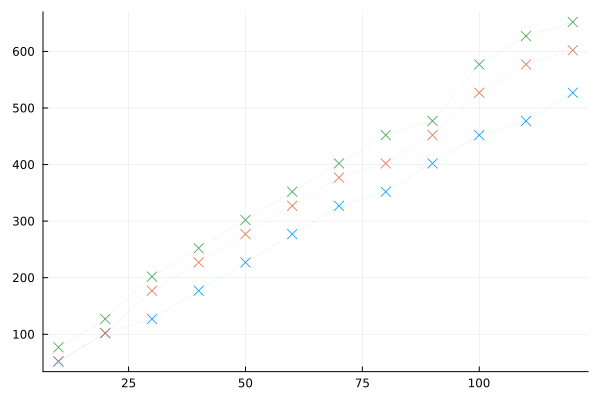

In [24]:
p = plot(mode_number_list, cp_rank_table, line=false, marker=:x, label=false, markersize=5)
display(p)

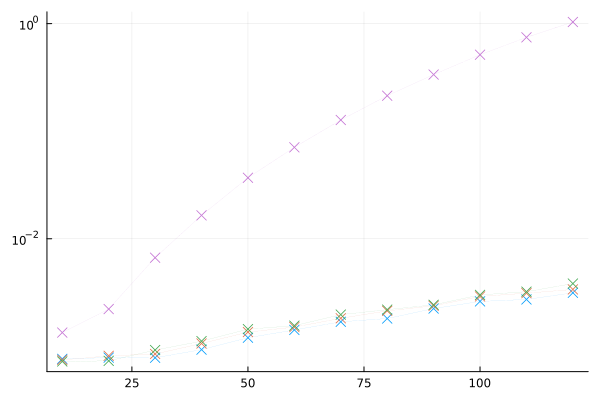

In [25]:
p = plot(mode_number_list, rhs_timing_list, line=false, marker=:x, label=false, markersize=5,yscale=:log10)
plot!(mode_number_list, dense_timing_list, line=false, marker=:x, label=false, markersize=5)

In [27]:
npzwrite("cp_rank_table_grin.npy", cp_rank_table)
npzwrite("rhs_timing_list_cp_grin.npy", rhs_timing_list)
npzwrite("dense_timing_list_grin.npy", dense_timing_list)

Case with asymmetric fiber

In [6]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^13;
time_window = 100; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength
λ_nm = 1e9 * λ;

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);

In [62]:
dx = dy = 1e-6;
x_grid = [-100e-6:dx:100e-6;];
y_grid = [-100e-6:dy:100e-6;];
grid_num = length(x_grid)

a = 50e-6;
b = 70e-6;

x_defect_1 = 20e-6
y_defect_1 = -25e-6;
R_defect_1 = 15e-6;
defect_1 = -0.002;

x_defect_2 = 0e-6
y_defect_2 = 25e-6;
R_defect_2 = 10e-6;
defect_2 = -0.0005;

## geometry = perturbed ellipse

function index_profile(x,y)

    ell = (x/a)^2 + (y/b)^2;

    if ell < 1
        index = 1.444023621703261; # taken from as n_hi and n_lo from an earlier step-index example arbitrarily
    else
        index = 1.4175962824573864;
    end

    circ_1 = ((x - x_defect_1)^2 + (y-y_defect_1)^2)/R_defect_1^2;

    if circ_1 < 1
        index += defect_1;
    end
    
    circ_2 = ((x - x_defect_2)^2 + (y-y_defect_2)^2)/R_defect_2^2;

    if circ_2 < 1
        index += defect_2;
    end

    return index
end

nxy = [index_profile(xx, yy) for yy in y_grid, xx in x_grid];

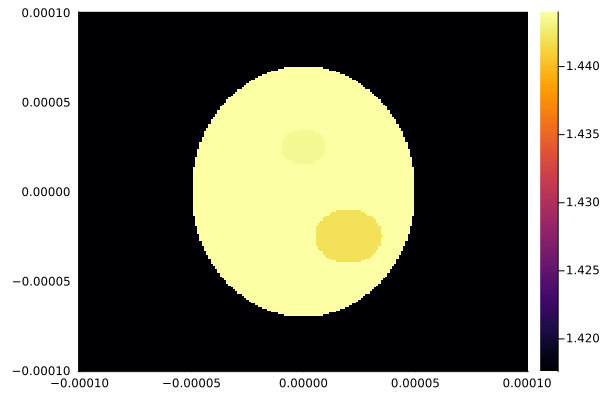

In [63]:
heatmap(x_grid,y_grid,nxy)

In [70]:
material = Silica();
profile = IndexProfile(x_grid,y_grid,nxy; lambda0=λ0);

num_modes = 120

properties = compute_fiber_properties(
    profile,
    material,
    num_modes;
    polarization=:scalar,
    mode_basis=:FD,                       # automatic for IndexProfile
    beta_order=5,
    dispersion_span=35.0,                 # rad/ps
    arpack_tol=1e-10,
    arpack_maxiter=10_000,
    tracking_padding=4,
)

FiberProperties{TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, AnisotropicRaman{Float64}, FiberModeData{Float64, Float64, Vector{@NamedTuple{family::Symbol, index::Int64, parity::Symbol}}}, @NamedTuple{profile::Symbol, material::Symbol, lambda0::Float64, core_radius::Nothing, NA::Nothing, num_modes::Int64, polarization::Symbol, mode_basis::Symbol, beta_order::Int64, dispersion_span::Float64, dispersion_samples::Int64, dispersion_fit_order::Int64, overlap::@NamedTuple{representation::Symbol, quadrature_order::Int64, chunk_points::Int64, max_workspace_bytes::Int64, precision::Symbol, max_tensor_bytes::Nothing}, wavelength_rule::Symbol, grid::@NamedTuple{nx::Int64, ny::Int64, xmin::Float64, xmax::Float64, ymin::Float64, ymax::Float64}}, Float64}(TaylorBeta{Float64, 2}([5.853304603129844e6 5.853140170642888e6 … 5.840853921493574e6 5.840780231523234e6; 4878.867176093337 4878.969158029542 … 4888.247559880871 4887.288126085673; … ; -4.946145432185471e-7 -4.976209885552037e-7 … 4.84091496494

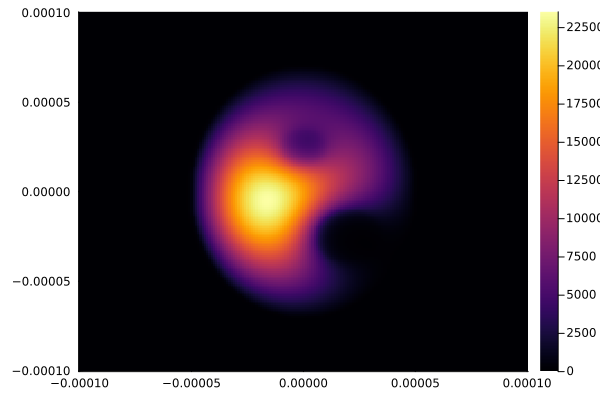

In [97]:
heatmap(x_grid,y_grid,properties.modes.fields[:,:,1])

In [87]:
mode_number_list = [10:10:120;];
error_list = [1e-2, 1e-3, 1e-4];
cp_rank_table = zeros(length(mode_number_list), length(error_list));

rhs_timing_list = zeros(length(mode_number_list), length(error_list));

dz_forward = 50e-6;
n_steps = 250;
L_fiber = n_steps * dz_forward;


In [ ]:
for ii = 1:length(error_list)
    err = error_list[ii];

    for mm = 1:length(mode_number_list)

        num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ### Constructing CP decomposition
        S_compressed = cp_compress(
                        S_m;
                        error=err,
                        backend=:cuda,
                        min_rank=2,       # choose using previous experience
                        rank_step=25,       # or 64
                        max_rank=1500,
                        maxiter=120,
                        tolerance=1e-6,
                        ridge=1e-8,
                        check_every=5,
                        )

        cp_rank_table[mm,ii] = length(S_compressed.λ)

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_compressed,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda_cp_optimized, precision=:mixed,
            adaptive=false);

        rhs_timing_list[mm,ii] = tsol / n_steps;

    end
end

10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120
10
20
30
40
50
60
70
80
90
100
110
120


In [ ]:
dense_timing_list = zeros(length(mode_number_list));

for mm = 1:length(mode_number_list)
        
    num_modes = mode_number_list[mm];
        #println(num_modes)

        beta_m = properties.beta.coefficients[:,1:num_modes];
        S_m = properties.S.values[1:num_modes,1:num_modes,1:num_modes,1:num_modes];

        ## Solving MMGNLSE for 250 steps to find average time per step.
        parameters = MMGNLSEParameters(domain;
            length=L_fiber,
            beta=TaylorBeta(beta_m),
            S=S_m,
            n2=properties.n2,
            omega0=properties.omega0,
            raman=properties.raman)

        coefficients = ones(ComplexF64, num_modes) 

        initial_field = gaussian_pulse(
            domain,
            num_modes;
            peak_power=1e6,    # total peak power across all modes, W
            fwhm=0.25,          # intensity FWHM, ps
            time_offset=0,  # ps
            coefficients=coefficients,
        );

        tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda, precision=:mixed,
             adaptive=false);

        #tsol = @elapsed solution = solve_mmgnlse(initial_field, parameters, dz_forward; backend=:cuda);

        dense_timing_list[mm] = tsol / n_steps;

end

10
20
30
40
50
60
70
80
90
100
110
120


In [98]:
npzwrite("xgrid_perturbed_ellipse.npy", x_grid)
npzwrite("index_perturbed_ellipse.npy", nxy)
npzwrite("first_mode_perturbed_ellipse.npy", properties.modes.fields[:,:,1])
npzwrite("cp_rank_table_step_perturbed_ellipse.npy", cp_rank_table)
npzwrite("rhs_timing_list_cp_step_perturbed_ellipse.npy", rhs_timing_list)
npzwrite("dense_timing_list_step_perturbed_ellipse.npy", dense_timing_list)